In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Sample data.xlsx")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 700
Columns: 16


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [5]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

Column Names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Data Types:
Segment                        object
Country                        object
Product                        object
Discount Band                  object
Units Sold                    float64
Manufacturing Price             int64
Sale Price                      int64
Gross Sales                   float64
Discounts                     float64
 Sales                        float64
COGS                          float64
Profit                        float64
Date                   datetime64[ns]
Month Number                    int64
Month Name                     object
Year                            int64
dtype: object

Dataset Shape:
(700, 16)


In [6]:
print("Missing Values:")
display(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

Missing Values:


Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

Duplicate Rows: 0


In [7]:
df.columns = df.columns.str.strip()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Discount Band"] = df["Discount Band"].fillna("Unknown")

df = df.drop_duplicates()

print("Cleaning completed")
print("Remaining rows:", len(df))
print("Remaining missing values:", df.isnull().sum().sum())

Cleaning completed
Remaining rows: 700
Remaining missing values: 0


In [8]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_units = df["Units Sold"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Units Sold:", round(total_units, 2))
print("Overall Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 118726350.26
Total Profit: 16893702.26
Total Units Sold: 1125806.0
Overall Profit Margin: 14.23 %


In [10]:
sales_country = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_country.to_frame("Total Sales"))

print("Top Country:", sales_country.index[0])

,Total Sales
Country,
United States of America,2.502983e+07
Canada,2.488765e+07
France,2.435417e+07
Germany,2.350534e+07
Mexico,2.094935e+07


Top Country: United States of America


In [11]:
profit_product = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

display(profit_product.to_frame("Total Profit"))

print("Most Profitable Product:", profit_product.index[0])

,Total Profit
Product,
Paseo,4797437.950
VTT,3034608.020
Amarilla,2814104.060
Velo,2305992.465
Montana,2114754.880
Carretera,1826804.885


Most Profitable Product: Paseo


In [12]:
sales_segment = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_segment.to_frame("Total Sales"))

print("Top Segment:", sales_segment.index[0])

,Total Sales
Segment,
Government,5.250426e+07
Small Business,4.242792e+07
Enterprise,1.961169e+07
Midmarket,2.381883e+06
Channel Partners,1.800594e+06


Top Segment: Government


In [13]:
sales_product = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_product.to_frame("Total Sales"))

print("Top Product:", sales_product.index[0])

,Total Sales
Product,
Paseo,3.301114e+07
VTT,2.051192e+07
Velo,1.825006e+07
Amarilla,1.774712e+07
Montana,1.539080e+07
Carretera,1.381531e+07


Top Product: Paseo


In [14]:
monthly_sales = (
    df.groupby("Month Number")["Sales"]
    .sum()
    .sort_index()
)

display(monthly_sales.to_frame("Total Sales"))

print("Highest Sales Month:", monthly_sales.idxmax())

,Total Sales
Month Number,
1,6607761.68
2,7297531.39
3,5586859.87
4,6964775.07
5,6210211.06
6,9518893.82
7,8102920.18
8,5864622.42
9,10882697.27


Highest Sales Month: 10


In [15]:
yearly_sales = df.groupby("Year")["Sales"].sum().sort_index()
yearly_profit = df.groupby("Year")["Profit"].sum().sort_index()

print("Yearly Sales")
display(yearly_sales.to_frame("Total Sales"))

print("Yearly Profit")
display(yearly_profit.to_frame("Total Profit"))

Yearly Sales


,Total Sales
Year,
2013,26415255.51
2014,92311094.75


Yearly Profit


,Total Profit
Year,
2013,3878464.51
2014,13015237.75


In [16]:
product_analysis = df.groupby("Product").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum")
)

product_analysis["Profit Margin (%)"] = (
    product_analysis["Profit"] /
    product_analysis["Sales"] * 100
)

product_analysis = product_analysis.sort_values(
    "Profit", ascending=False
)

display(product_analysis)

,Sales,Profit,Units_Sold,Profit Margin (%)
Product,,,,
Paseo,3.301114e+07,4797437.950,338239.5,14.532783
VTT,2.051192e+07,3034608.020,168783.0,14.794363
Amarilla,1.774712e+07,2814104.060,155315.0,15.856684
Velo,1.825006e+07,2305992.465,162424.5,12.635534
Montana,1.539080e+07,2114754.880,154198.0,13.740381
Carretera,1.381531e+07,1826804.885,146846.0,13.223049


In [17]:
country_analysis = df.groupby("Country").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum")
)

country_analysis["Profit Margin (%)"] = (
    country_analysis["Profit"] /
    country_analysis["Sales"] * 100
)

country_analysis = country_analysis.sort_values(
    "Sales", ascending=False
)

display(country_analysis)

,Sales,Profit,Units_Sold,Profit Margin (%)
Country,,,,
United States of America,2.502983e+07,2995540.665,232627.5,11.967883
Canada,2.488765e+07,3529228.885,247428.5,14.180641
France,2.435417e+07,3781020.780,240931.0,15.525146
Germany,2.350534e+07,3680388.820,201494.0,15.657671
Mexico,2.094935e+07,2907523.110,203325.0,13.878821


In [18]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum")
)

segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] /
    segment_analysis["Sales"] * 100
)

segment_analysis = segment_analysis.sort_values(
    "Sales", ascending=False
)

display(segment_analysis)

,Sales,Profit,Units_Sold,Profit Margin (%)
Segment,,,,
Government,5.250426e+07,1.138817e+07,470673.5,21.689998
Small Business,4.242792e+07,4.143168e+06,153139.0,9.765194
Enterprise,1.961169e+07,-6.145456e+05,168552.0,-3.133567
Midmarket,2.381883e+06,6.601031e+05,172178.0,27.713496
Channel Partners,1.800594e+06,1.316803e+06,161263.5,73.131611


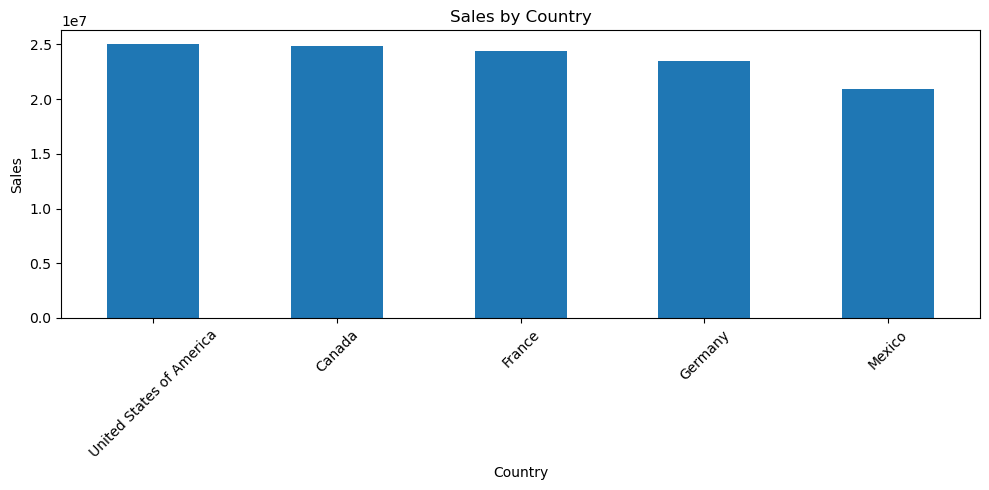

In [19]:
plt.figure(figsize=(10, 5))
sales_country.plot(kind="bar")
plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

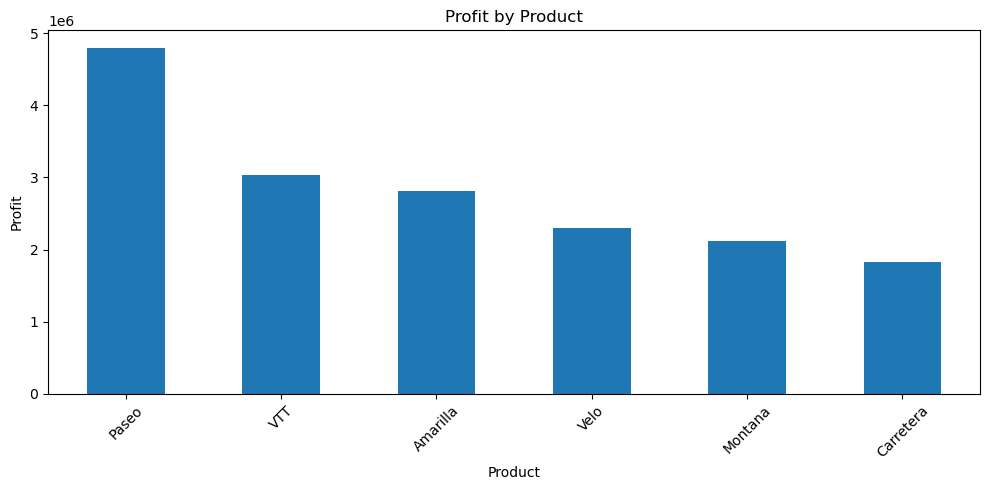

In [20]:
plt.figure(figsize=(10, 5))
profit_product.plot(kind="bar")
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

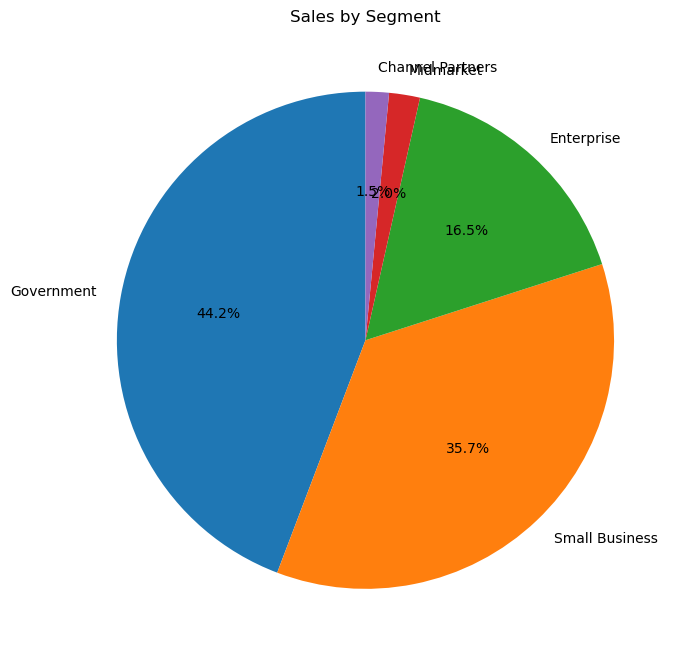

In [21]:
plt.figure(figsize=(7, 7))
sales_segment.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales by Segment")
plt.ylabel("")
plt.tight_layout()
plt.show()

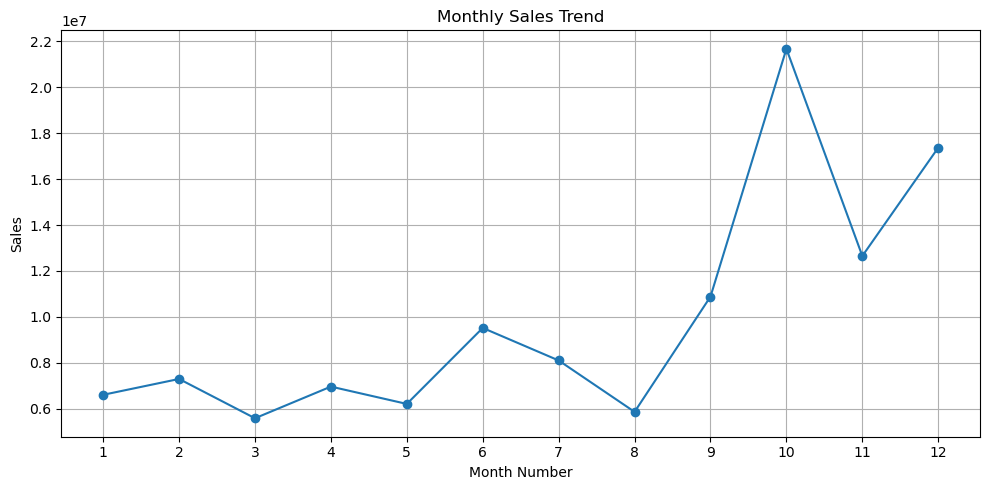

In [22]:
plt.figure(figsize=(10, 5))
monthly_sales.plot(
    kind="line",
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

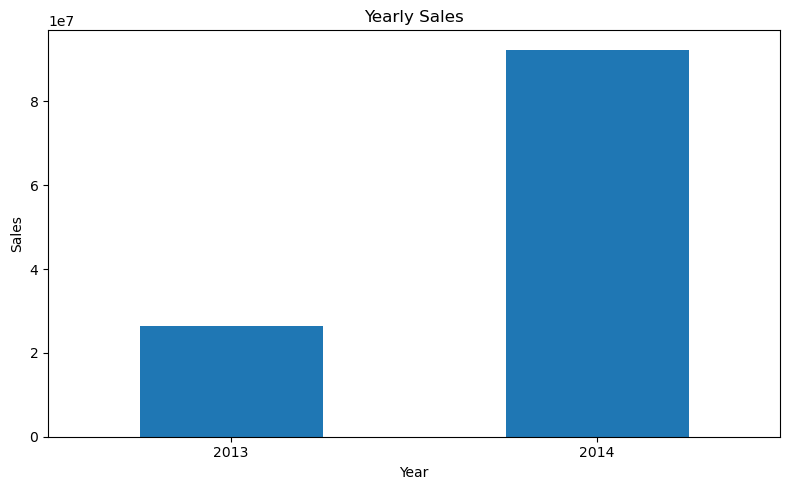

In [23]:
plt.figure(figsize=(8, 5))
yearly_sales.plot(kind="bar")
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
print("BUSINESS INSIGHTS")
print("-" * 40)

print(
    "Top Country:",
    sales_country.index[0],
    "| Sales:",
    round(sales_country.iloc[0], 2)
)

print(
    "Most Profitable Product:",
    profit_product.index[0],
    "| Profit:",
    round(profit_product.iloc[0], 2)
)

print(
    "Top Segment:",
    sales_segment.index[0],
    "| Sales:",
    round(sales_segment.iloc[0], 2)
)

print(
    "Best Sales Month:",
    monthly_sales.idxmax(),
    "| Sales:",
    round(monthly_sales.max(), 2)
)

print(
    "Overall Profit Margin:",
    round(profit_margin, 2),
    "%"
)

BUSINESS INSIGHTS
----------------------------------------
Top Country: United States of America | Sales: 25029830.16
Most Profitable Product: Paseo | Profit: 4797437.95
Top Segment: Government | Sales: 52504260.67
Best Sales Month: 10 | Sales: 21671431.02
Overall Profit Margin: 14.23 %


In [25]:
print("RECOMMENDATIONS")
print("-" * 40)

print("1. Focus on high-performing countries and strengthen successful markets.")
print("2. Prioritize products with strong sales and profitability.")
print("3. Improve strategies for lower-performing business segments.")
print("4. Use monthly sales trends for inventory and sales planning.")
print("5. Monitor profit margins while planning discounts and promotions.")

RECOMMENDATIONS
----------------------------------------
1. Focus on high-performing countries and strengthen successful markets.
2. Prioritize products with strong sales and profitability.
3. Improve strategies for lower-performing business segments.
4. Use monthly sales trends for inventory and sales planning.
5. Monitor profit margins while planning discounts and promotions.


In [26]:
df.to_excel(
    "Cleaned_Sample_Data.xlsx",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [27]:
with pd.ExcelWriter("Capstone_Analysis_Results.xlsx") as writer:

    sales_country.to_frame("Total Sales").to_excel(
        writer, sheet_name="Sales by Country"
    )

    profit_product.to_frame("Total Profit").to_excel(
        writer, sheet_name="Profit by Product"
    )

    sales_segment.to_frame("Total Sales").to_excel(
        writer, sheet_name="Sales by Segment"
    )

    sales_product.to_frame("Total Sales").to_excel(
        writer, sheet_name="Sales by Product"
    )

    monthly_sales.to_frame("Total Sales").to_excel(
        writer, sheet_name="Monthly Sales"
    )

    yearly_sales.to_frame("Total Sales").to_excel(
        writer, sheet_name="Yearly Sales"
    )

    product_analysis.to_excel(
        writer, sheet_name="Product Analysis"
    )

    country_analysis.to_excel(
        writer, sheet_name="Country Analysis"
    )

    segment_analysis.to_excel(
        writer, sheet_name="Segment Analysis"
    )

print("Capstone analysis Excel file created.")

Capstone analysis Excel file created.


In [28]:
import os

print(os.getcwd())
print("\nFiles in this folder:")
print(os.listdir())

C:\Users\Parth

Files in this folder:
['-1.14-windows.xml', '.anaconda', '.android', '.arduinoIDE', '.cache', '.conda', '.continuum', '.copilot', '.eclipse', '.emulator_console_auth_token', '.ghcp-appmod', '.ghcp-appmod-java', '.gradle', '.idlerc', '.insomniac', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.m2', '.matplotlib', '.p2', '.packettracer', '.redhat', '.VirtualBox', '.vscode', '.vscode-shared', 'anaconda3', 'app.js', 'AppData', 'Application Data', 'c tutorial', 'Capstone_Analysis_Results.xlsx', 'Cisco Packet Tracer 6.2sv', 'Cleaned_Sample_Data.xlsx', 'Contacts', 'Cookies', 'css tutorials', 'dataset.xlsx', 'Desktop', 'Documents', 'Downloads', 'eclipse-workspace', 'Employee.csv', 'extension.zip', 'Favorites', 'flut', 'ge,imi', 'healthcare_basic_dataset.csv', 'IdeaProjects', 'IdeaSnapshots', 'IOT', 'java2', 'java_error_in_studio_30340.log', 'java_questions', 'Links', 'Local Settings', 'LOgin page', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser